In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import re

from wordcloud import WordCloud

# Load and Preprocess Data

In [44]:
df = pd.read_csv('df_text_eng.csv')
df.fillna('',inplace=True)
df = df.drop(columns=['Unnamed: 0'], axis=1)
df.head()

,blurb,state
0,"Using their own character, users go on educati...",failed
1,"MicroFly is a quadcopter packed with WiFi, 6 s...",successful
2,"A small indie press, run as a collective for a...",failed
3,Zylor is a new baby cosplayer! Back this kicks...,failed
4,Hatoful Boyfriend meet Skeletons! A comedy Dat...,failed


In [45]:
df['state'].value_counts(normalize=True) * 100

state
successful    50.256829
failed        49.743171
Name: proportion, dtype: float64

In [46]:
df['text_clean'] = df['blurb'].str.replace(f"[{string.punctuation}]", "", regex=True)
df.head()

,blurb,state,text_clean
0,"Using their own character, users go on educati...",failed,Using their own character users go on educatio...
1,"MicroFly is a quadcopter packed with WiFi, 6 s...",successful,MicroFly is a quadcopter packed with WiFi 6 se...
2,"A small indie press, run as a collective for a...",failed,A small indie press run as a collective for au...
3,Zylor is a new baby cosplayer! Back this kicks...,failed,Zylor is a new baby cosplayer Back this kickst...
4,Hatoful Boyfriend meet Skeletons! A comedy Dat...,failed,Hatoful Boyfriend meet Skeletons A comedy Dati...


In [47]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))
pronouns = ['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves']

def clean_text(text):
    tokens = word_tokenize(text.lower())
    filtered_tokens = [word for word in tokens if word not in stop_words and word not in pronouns]
    return ' '.join(filtered_tokens)

df['text_clean_1'] = df['text_clean'].apply(clean_text)
df.head()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\gmgma\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gmgma\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,blurb,state,text_clean,text_clean_1
0,"Using their own character, users go on educati...",failed,Using their own character users go on educatio...,using character users go educational quests ar...
1,"MicroFly is a quadcopter packed with WiFi, 6 s...",successful,MicroFly is a quadcopter packed with WiFi 6 se...,microfly quadcopter packed wifi 6 sensors 3 pr...
2,"A small indie press, run as a collective for a...",failed,A small indie press run as a collective for au...,small indie press run collective authors want ...
3,Zylor is a new baby cosplayer! Back this kicks...,failed,Zylor is a new baby cosplayer Back this kickst...,zylor new baby cosplayer back kickstarter help...
4,Hatoful Boyfriend meet Skeletons! A comedy Dat...,failed,Hatoful Boyfriend meet Skeletons A comedy Dati...,hatoful boyfriend meet skeletons comedy dating...


In [48]:
from nltk.corpus import wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# download NLTK resources
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

# Initialize the WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

# funtion to get the part of speech tag for lemmatization
def get_wordnet_pos(word):
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ,
                "N": wordnet.NOUN,
                "V": wordnet.VERB,
                "R": wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)

def lemmatize_text(text):
    words = word_tokenize(text)
    lemmatized_words = [lemmatizer.lemmatize(word, get_wordnet_pos(word)) for word in words]
    return ' '.join(lemmatized_words)

df['text_clean_2'] = df['text_clean_1'].apply(lemmatize_text)
df.head()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\gmgma\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\gmgma\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\gmgma\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


,blurb,state,text_clean,text_clean_1,text_clean_2
0,"Using their own character, users go on educati...",failed,Using their own character users go on educatio...,using character users go educational quests ar...,use character user go educational quest around...
1,"MicroFly is a quadcopter packed with WiFi, 6 s...",successful,MicroFly is a quadcopter packed with WiFi 6 se...,microfly quadcopter packed wifi 6 sensors 3 pr...,microfly quadcopter packed wifi 6 sensor 3 pro...
2,"A small indie press, run as a collective for a...",failed,A small indie press run as a collective for au...,small indie press run collective authors want ...,small indie press run collective author want s...
3,Zylor is a new baby cosplayer! Back this kicks...,failed,Zylor is a new baby cosplayer Back this kickst...,zylor new baby cosplayer back kickstarter help...,zylor new baby cosplayer back kickstarter help...
4,Hatoful Boyfriend meet Skeletons! A comedy Dat...,failed,Hatoful Boyfriend meet Skeletons A comedy Dati...,hatoful boyfriend meet skeletons comedy dating...,hatoful boyfriend meet skeleton comedy date si...


In [49]:
# function to remove numbers
def remove_numbers(text):
    return re.sub(r'\d+', '', text)

df['text_clean_3'] = df['text_clean_2'].apply(remove_numbers)
df.head()

,blurb,state,text_clean,text_clean_1,text_clean_2,text_clean_3
0,"Using their own character, users go on educati...",failed,Using their own character users go on educatio...,using character users go educational quests ar...,use character user go educational quest around...,use character user go educational quest around...
1,"MicroFly is a quadcopter packed with WiFi, 6 s...",successful,MicroFly is a quadcopter packed with WiFi 6 se...,microfly quadcopter packed wifi 6 sensors 3 pr...,microfly quadcopter packed wifi 6 sensor 3 pro...,microfly quadcopter packed wifi sensor proce...
2,"A small indie press, run as a collective for a...",failed,A small indie press run as a collective for au...,small indie press run collective authors want ...,small indie press run collective author want s...,small indie press run collective author want s...
3,Zylor is a new baby cosplayer! Back this kicks...,failed,Zylor is a new baby cosplayer Back this kickst...,zylor new baby cosplayer back kickstarter help...,zylor new baby cosplayer back kickstarter help...,zylor new baby cosplayer back kickstarter help...
4,Hatoful Boyfriend meet Skeletons! A comedy Dat...,failed,Hatoful Boyfriend meet Skeletons A comedy Dati...,hatoful boyfriend meet skeletons comedy dating...,hatoful boyfriend meet skeleton comedy date si...,hatoful boyfriend meet skeleton comedy date si...


In [50]:
df_clean = df[['text_clean_3', 'state']]
df_clean = df_clean.rename(columns={'text_clean_3': 'text', 'state': 'status'})
df_clean.head()

,text,status
0,use character user go educational quest around...,failed
1,microfly quadcopter packed wifi sensor proce...,successful
2,small indie press run collective author want s...,failed
3,zylor new baby cosplayer back kickstarter help...,failed
4,hatoful boyfriend meet skeleton comedy date si...,failed


# Exploratory Data Analysis (EDA)

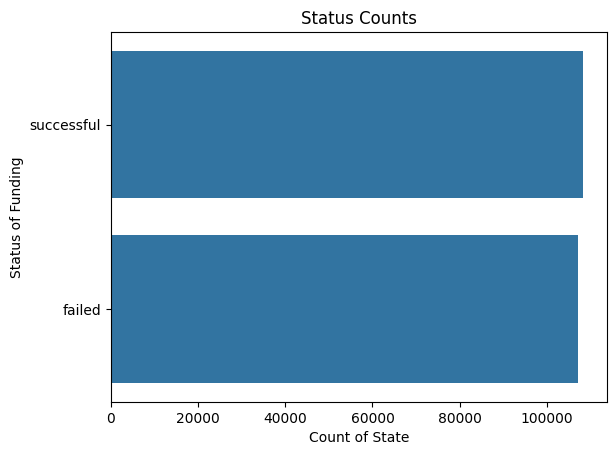

In [51]:
# plotting status counts
sns.countplot(df_clean['status'], order = df_clean['status'].value_counts().index)
plt.xlabel('Count of State')
plt.ylabel('Status of Funding')
plt.title('Status Counts')
plt.show()

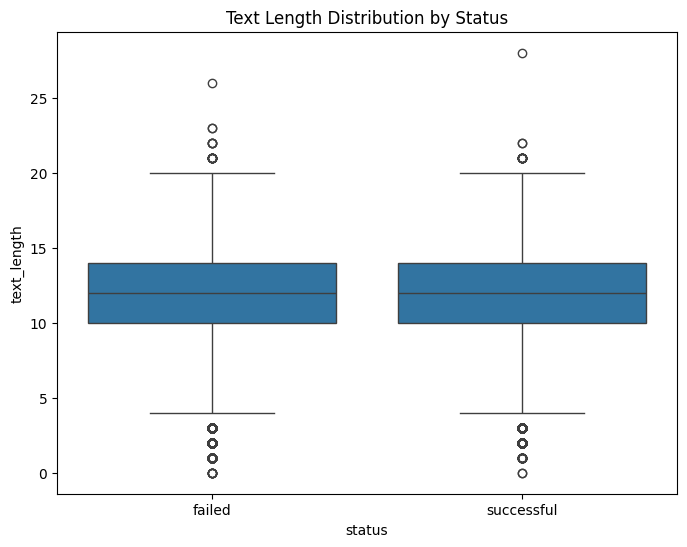

In [52]:
# Calculate text length
df_clean['text_length'] = df_clean['text'].apply(lambda x: len(x.split()))

# Plot distribution of text length for each status
plt.figure(figsize=(8, 6))
sns.boxplot(x='status', y='text_length', data=df_clean)
plt.title('Text Length Distribution by Status')
plt.show()

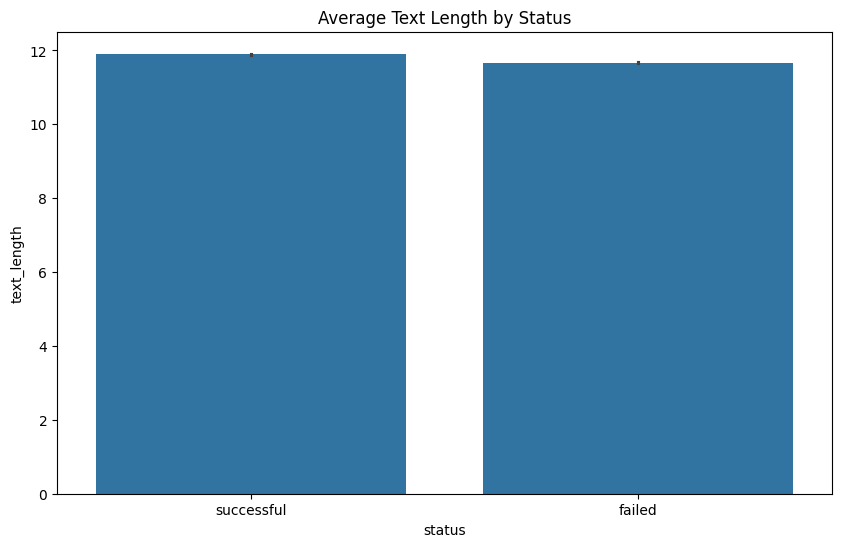

In [53]:
# Average length by status bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='status', y='text_length', data=df_clean, order= df_clean.groupby('status')['text_length'].mean().sort_values(ascending=False).index)
plt.title('Average Text Length by Status')
plt.show()

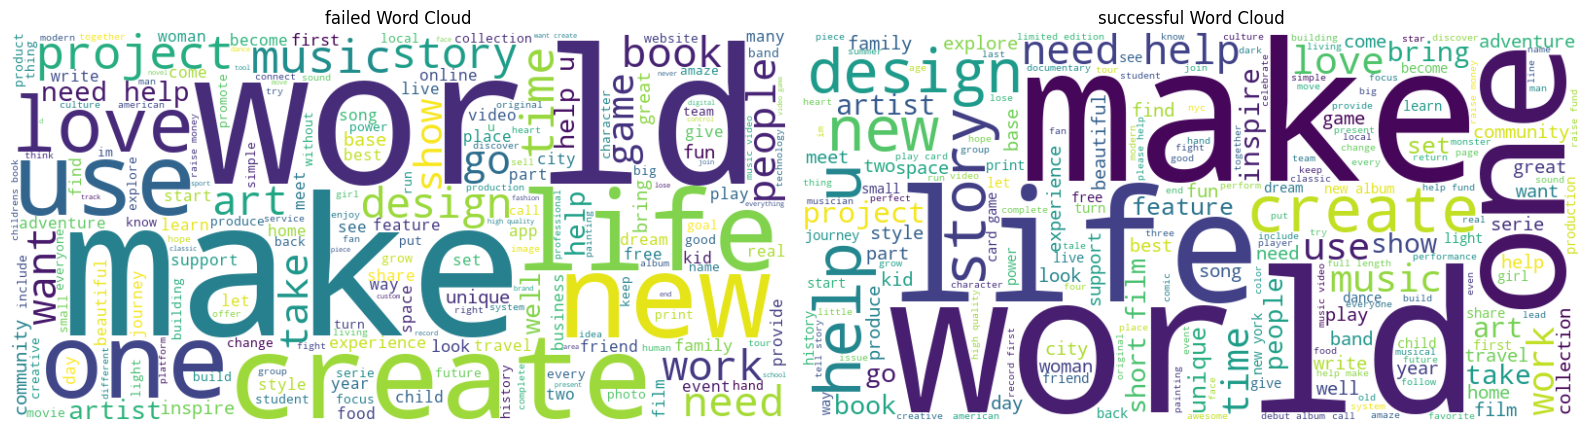

In [54]:
# Generate word cloud for status classes
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Get unique statuses excluding 'Normal'
statuses = df_clean['status'].unique()

for i, status in enumerate(statuses):
    # Combine all statements for the current status
    text = ' '.join(df_clean[df_clean['status'] == status]['text'])
    
    # Generate word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    
    # Display word cloud
    ax[i].imshow(wordcloud, interpolation='bilinear')
    ax[i].set_title(f'{status} Word Cloud')
    ax[i].axis('off')

plt.tight_layout()
plt.show()

In [55]:
df_clean.drop(columns=['text_length'], inplace=True)
df_clean.head()

,text,status
0,use character user go educational quest around...,failed
1,microfly quadcopter packed wifi sensor proce...,successful
2,small indie press run collective author want s...,failed
3,zylor new baby cosplayer back kickstarter help...,failed
4,hatoful boyfriend meet skeleton comedy date si...,failed


# Modeling

In [56]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

tfidf_vectorizer = TfidfVectorizer(
    max_features=100,
    max_df=0.8,  # Remove words that appear in more than 80% of documents
    min_df=5,    # Remove words that appear in fewer than 5 documents
    stop_words='english'
)

# Fit and transform the cleaned text data
tfidf_matrix = tfidf_vectorizer.fit_transform(df_clean['text'])

print(f'TF-IDF matrix shape: {tfidf_matrix.shape}')
print(f'Number of features: {len(tfidf_vectorizer.get_feature_names_out())}')

# Initialize LDA with 5 topics
n_topics = 5
lda_model = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    max_iter=100,
    learning_method='batch'
)

# Fit the LDA model to the TF-IDF matrix
lda_topic_features = lda_model.fit_transform(tfidf_matrix)

print(f'LDA topic features shape: {lda_topic_features.shape}')

def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]))
        
no_top_words = 10
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
display_topics(lda_model, tfidf_feature_names, no_top_words)

TF-IDF matrix shape: (215513, 100)
Number of features: 100
LDA topic features shape: (215513, 5)
Topic 0:
world album record story help set new people song friend
Topic 1:
make film time design feature music short video adventure want
Topic 2:
life create work bring like food day start help inspire
Topic 3:
game use help play need base unique love card family
Topic 4:
book art year series new way young print write woman


In [57]:
# Using LDA topics to assign industry labels
industry_map_lda = {
    0: "Music",
    1: "Film/Media",
    2: "Lifestyle",
    3: "Games",
    4: "Publishing/Art"
}

# 2. Extract argmax topic indices
df_clean["lda_topic"] = np.argmax(lda_topic_features, axis=1)

# 3. Map to industries
df_clean["industry_lda"] = df_clean["lda_topic"].map(industry_map_lda)
df_clean.head()

,text,status,lda_topic,industry_lda
0,use character user go educational quest around...,failed,3,Games
1,microfly quadcopter packed wifi sensor proce...,successful,0,Music
2,small indie press run collective author want s...,failed,1,Film/Media
3,zylor new baby cosplayer back kickstarter help...,failed,0,Music
4,hatoful boyfriend meet skeleton comedy date si...,failed,0,Music


In [58]:
from sklearn.decomposition import NMF

nmf_model = NMF(
    n_components=n_topics,
    random_state=42,
    max_iter=200,
    alpha_W=0,    # Regularization parameter for W
    alpha_H=0,    # Regularization parameter for H
    l1_ratio=0.5    # Balance between L1 and L2 regularization
)

# Fit the NMF model to the TF-IDF matrix
nmf_topic_features = nmf_model.fit_transform(tfidf_matrix)

print(f'NMF topic features shape: {nmf_topic_features.shape}')

display_topics(nmf_model, tfidf_feature_names, no_top_words)

NMF topic features shape: (215513, 5)
Topic 0:
new album music record song work release city feature way
Topic 1:
make want design use music love im like people unique
Topic 2:
game card play video fun adventure design use base set
Topic 3:
book world story life art create film love series project
Topic 4:
help need album record fund release music bring support raise


In [59]:
# Using NMF topics to assign industry labels
industry_map_nmf = {
    0: "Music",
    1: "Design",
    2: "Games",
    3: "Publishing/Film/Art",
    4: "Community"
}

# Extract argmax topic indices
df_clean["nmf_topic"] = np.argmax(nmf_topic_features, axis=1)

# Map to industries
df_clean["industry_nmf"] = df_clean["nmf_topic"].map(industry_map_nmf)
df_clean.head()

,text,status,lda_topic,industry_lda,nmf_topic,industry_nmf
0,use character user go educational quest around...,failed,3,Games,3,Publishing/Film/Art
1,microfly quadcopter packed wifi sensor proce...,successful,0,Music,0,Music
2,small indie press run collective author want s...,failed,1,Film/Media,3,Publishing/Film/Art
3,zylor new baby cosplayer back kickstarter help...,failed,0,Music,4,Community
4,hatoful boyfriend meet skeleton comedy date si...,failed,0,Music,3,Publishing/Film/Art


In [60]:
# Combined industry text label
df_clean["industry_combined"] = (
    df_clean["industry_nmf"] + "_" + df_clean["industry_lda"]
)

# Numeric encoding
df_clean["industry_combined_id"] = (
    df_clean["industry_combined"].astype("category").cat.codes
)

# Agreement binary feature
df_clean["industry_agree"] = (df_clean["industry_nmf"] == df_clean["industry_lda"]).astype(int)
df_clean.head()

,text,status,lda_topic,industry_lda,nmf_topic,industry_nmf,industry_combined,industry_combined_id,industry_agree
0,use character user go educational quest around...,failed,3,Games,3,Publishing/Film/Art,Publishing/Film/Art_Games,21,0
1,microfly quadcopter packed wifi sensor proce...,successful,0,Music,0,Music,Music_Music,18,1
2,small indie press run collective author want s...,failed,1,Film/Media,3,Publishing/Film/Art,Publishing/Film/Art_Film/Media,20,0
3,zylor new baby cosplayer back kickstarter help...,failed,0,Music,4,Community,Community_Music,3,0
4,hatoful boyfriend meet skeleton comedy date si...,failed,0,Music,3,Publishing/Film/Art,Publishing/Film/Art_Music,23,0


In [61]:
# reformatting for modeling purposes
industry_nmf = df_clean["nmf_topic"].values.reshape(-1, 1)
industry_lda = df_clean["lda_topic"].values.reshape(-1, 1)
industry_combined = df_clean["industry_combined_id"].values.reshape(-1, 1)
industry_agree = df_clean["industry_agree"].values.reshape(-1, 1)

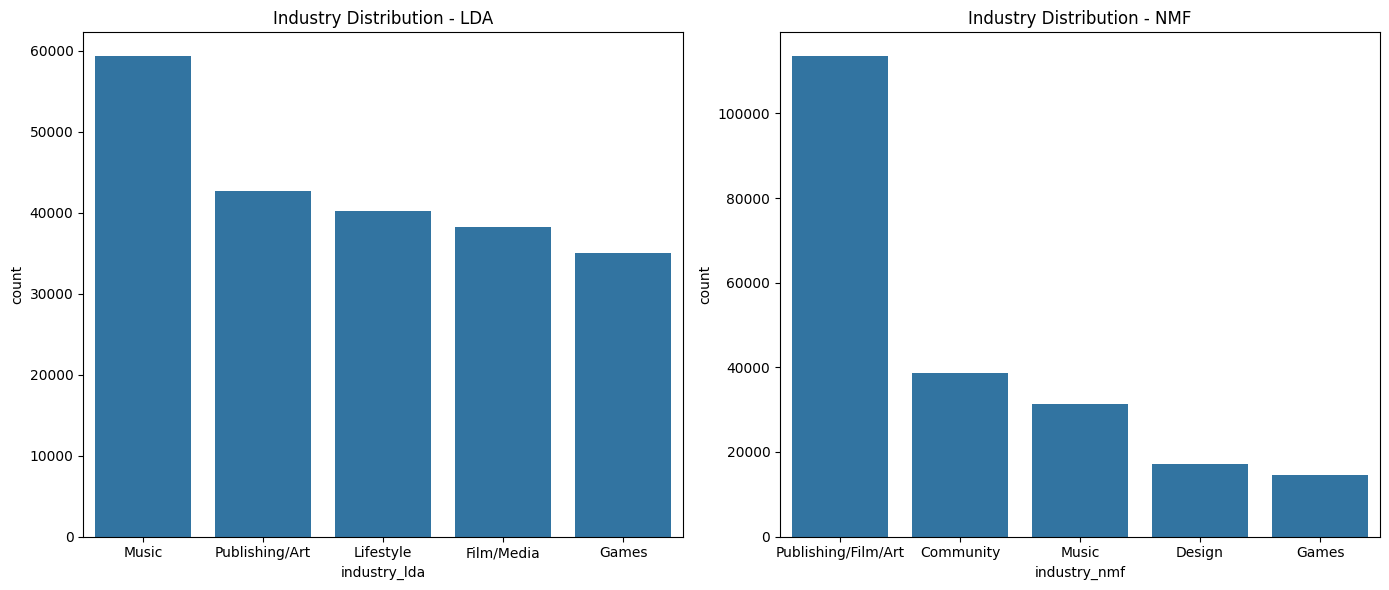

In [62]:
# plotting industry distribution for lda and nmf
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.countplot(x='industry_lda', data=df_clean, order=df_clean['industry_lda'].value_counts().index, ax=axes[0])
axes[0].set_title('Industry Distribution - LDA')

sns.countplot(x='industry_nmf', data=df_clean, order=df_clean['industry_nmf'].value_counts().index, ax=axes[1])
axes[1].set_title('Industry Distribution - NMF')

plt.tight_layout()
plt.show()

In [63]:
from sentence_transformers import SentenceTransformer

print("loading BERT model...")
bert_model = SentenceTransformer('all-MiniLM-L6-v2')
print("Model loaded.")

# Generate BERT embeddings for the cleaned text
print("Generating BERT embeddings...")
bert_embeddings = bert_model.encode(df_clean['text'].tolist(), show_progress_bar=True, batch_size=32)

print(f'BERT embeddings shape: {bert_embeddings.shape}')
print(f'each document is represented by a {bert_embeddings.shape[1]}-dimensional vector')

loading BERT model...
Model loaded.
Generating BERT embeddings...


Batches:   0%|          | 0/6735 [00:00<?, ?it/s]

BERT embeddings shape: (215513, 384)
each document is represented by a 384-dimensional vector


In [64]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Defining the KMeans model
kmeans_md = KMeans(n_clusters=3, n_init=20, random_state=42)

# Scaling the embeddings before clustering
scaler = StandardScaler()
bert_embeddings_scaled = scaler.fit_transform(bert_embeddings)

# Fitting the KMeans model
kmeans_md.fit(bert_embeddings_scaled)

# Getting cluster labels
cluster_labels = kmeans_md.labels_

# Assign cluster labels to original data
df_clean['cluster'] = cluster_labels
print(df_clean[['text', 'cluster']].head(5))

# Computing the distance of each point to each cluster center
X_kmeans_features = kmeans_md.transform(bert_embeddings_scaled)

print(f"KMeans feature shape: {X_kmeans_features.shape}")

                                                text  cluster
0  use character user go educational quest around...        0
1  microfly quadcopter packed wifi  sensor  proce...        2
2  small indie press run collective author want s...        0
3  zylor new baby cosplayer back kickstarter help...        2
4  hatoful boyfriend meet skeleton comedy date si...        0
KMeans feature shape: (215513, 3)


In [65]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics.pairwise import euclidean_distances

# MiniBatchKMeans clustering
mini_clust = MiniBatchKMeans(n_clusters=3, batch_size=1024, random_state=42)
mini_clust.fit(bert_embeddings_scaled)

# Assign labels
df_clean['mini_cluster'] = mini_clust.labels_
print(df_clean[['text', 'mini_cluster']].head(5))

# Get centroids directly
centroids = mini_clust.cluster_centers_

# Compute distances to each cluster center
X_mini_features = euclidean_distances(bert_embeddings_scaled, centroids)

print(f"Mini KMeans feature shape: {X_mini_features.shape}")

                                                text  mini_cluster
0  use character user go educational quest around...             2
1  microfly quadcopter packed wifi  sensor  proce...             0
2  small indie press run collective author want s...             2
3  zylor new baby cosplayer back kickstarter help...             0
4  hatoful boyfriend meet skeleton comedy date si...             2
Mini KMeans feature shape: (215513, 3)


In [66]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer

# target variable
y = df_clean['status'].map({'successful': 1, 'failed': 0}).values

# initialize CountVectorizer with a maximum of 30 features
vectorizer = CountVectorizer(max_features=30)

print("Comparing model performance with different feature sets:")
print("==" * 50)

X_vec = vectorizer.fit_transform(df_clean['text']).toarray()

feature_sets = {
    'Vectorized': X_vec,
    'LDA': lda_topic_features,
    'NMF': nmf_topic_features,
    'LDA_NMF': np.hstack([lda_topic_features, nmf_topic_features]),
    'Combined': np.hstack([vectorizer.fit_transform(df_clean['text']).toarray(), lda_topic_features, nmf_topic_features]),
    'Industry_Labels_Only': industry_combined,
    'Industry_Label_LDA': industry_lda,
    'Industry_Label_NMF': industry_nmf,
    'LDA_TF_Industry_Labels': np.hstack([lda_topic_features, industry_lda]),
    'NMF_TF_Industry_Labels': np.hstack([nmf_topic_features, industry_nmf]),
    'LDA_NMF_Industry_Label': np.hstack([lda_topic_features, nmf_topic_features, industry_combined]),
    'Vectorized_Industry_Label_lda': np.hstack([X_vec, industry_lda]),
    'Vectorized_Industry_Label_nmf': np.hstack([X_vec, industry_nmf]),
    'Vectorized_Industry_Label_comb': np.hstack([X_vec, industry_combined]),
    'kmeans': X_kmeans_features,
    'mini': X_mini_features,
    'bert': bert_embeddings,
    'kmeans_bert': np.hstack((X_kmeans_features, bert_embeddings)),
    'mini_bert': np.hstack((X_mini_features, bert_embeddings)),
    'kmeans_mini_bert': np.hstack((X_kmeans_features, X_mini_features, bert_embeddings)),
    'BERT_Industry_Label_lda': np.hstack([bert_embeddings, industry_lda]),
    'BERT_Industry_Label_nmf': np.hstack([bert_embeddings, industry_nmf]),
    'BERT_Industry_Label': np.hstack([bert_embeddings, industry_combined]),
}

# Stratified Group K-Fold Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=200))

logit_results = {}
for name, X in feature_sets.items():
    scores = cross_val_score(model, X, y, cv=skf, scoring='f1', n_jobs=-1)
    logit_results[name] = scores
    print(f"{name} Features: Mean F1 = {scores.mean():.4f}, Std = {scores.std():.4f}")
    
# Identify the best feature set
best_feature_set = max(logit_results, key=lambda k: logit_results[k].mean())
print(f"\n Best Feature Set: {best_feature_set} with Mean F1 = {logit_results[best_feature_set].mean():.4f}")

Comparing model performance with different feature sets:
Vectorized Features: Mean F1 = 0.5959, Std = 0.0021
LDA Features: Mean F1 = 0.5835, Std = 0.0022
NMF Features: Mean F1 = 0.4124, Std = 0.0013
LDA_NMF Features: Mean F1 = 0.5309, Std = 0.0023
Combined Features: Mean F1 = 0.5501, Std = 0.0024
Industry_Labels_Only Features: Mean F1 = 0.4253, Std = 0.0009
Industry_Label_LDA Features: Mean F1 = 0.5630, Std = 0.0020
Industry_Label_NMF Features: Mean F1 = 0.6689, Std = 0.0000
LDA_TF_Industry_Labels Features: Mean F1 = 0.5623, Std = 0.0188
NMF_TF_Industry_Labels Features: Mean F1 = 0.4167, Std = 0.0018
LDA_NMF_Industry_Label Features: Mean F1 = 0.5320, Std = 0.0022
Vectorized_Industry_Label_lda Features: Mean F1 = 0.5654, Std = 0.0054
Vectorized_Industry_Label_nmf Features: Mean F1 = 0.5699, Std = 0.0115
Vectorized_Industry_Label_comb Features: Mean F1 = 0.5909, Std = 0.0012
kmeans Features: Mean F1 = 0.5539, Std = 0.0039
mini Features: Mean F1 = 0.5526, Std = 0.0044
bert Features: Mean 

In [68]:
from sklearn.ensemble import RandomForestClassifier

print("Comparing model performance with different feature sets:")
print("==" * 50)

# Stratified Group K-Fold Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = make_pipeline(StandardScaler(), RandomForestClassifier(n_estimators=198, max_depth=7, min_samples_split=5, min_samples_leaf=7, random_state=42, n_jobs=-1))

rf_results = {}
for name, X in feature_sets.items():
    scores = cross_val_score(model, X, y, cv=skf, scoring='f1', n_jobs=-1)
    rf_results[name] = scores
    print(f"{name} Features: Mean F1 = {scores.mean():.4f}, Std = {scores.std():.4f}")
    
# Identify the best feature set
best_feature_set = max(rf_results, key=lambda k: rf_results[k].mean())
print(f"\n Best Feature Set: {best_feature_set} with Mean F1 = {rf_results[best_feature_set].mean():.4f}")

Comparing model performance with different feature sets:
Vectorized Features: Mean F1 = 0.4619, Std = 0.0054
LDA Features: Mean F1 = 0.5429, Std = 0.0031
NMF Features: Mean F1 = 0.5902, Std = 0.0144
LDA_NMF Features: Mean F1 = 0.5635, Std = 0.0145
Combined Features: Mean F1 = 0.5924, Std = 0.0030
Industry_Labels_Only Features: Mean F1 = 0.5641, Std = 0.0040
Industry_Label_LDA Features: Mean F1 = 0.5891, Std = 0.0021
Industry_Label_NMF Features: Mean F1 = 0.4625, Std = 0.0021
LDA_TF_Industry_Labels Features: Mean F1 = 0.5433, Std = 0.0042
NMF_TF_Industry_Labels Features: Mean F1 = 0.5665, Std = 0.0143
LDA_NMF_Industry_Label Features: Mean F1 = 0.5629, Std = 0.0135
Vectorized_Industry_Label_lda Features: Mean F1 = 0.5513, Std = 0.0039
Vectorized_Industry_Label_nmf Features: Mean F1 = 0.4664, Std = 0.0097
Vectorized_Industry_Label_comb Features: Mean F1 = 0.5727, Std = 0.0052
kmeans Features: Mean F1 = 0.5599, Std = 0.0036
mini Features: Mean F1 = 0.5674, Std = 0.0040
bert Features: Mean 

In [69]:
from xgboost import XGBClassifier

print("Comparing model performance with different feature sets:")
print("==" * 50)

# Stratified Group K-Fold Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = make_pipeline(StandardScaler(), XGBClassifier(n_estimators=217, max_depth=5, learning_rate=0.03493084488556003, random_state=42))

xgb_results = {}
for name, X in feature_sets.items():
    scores = cross_val_score(model, X, y, cv=skf, scoring='f1', n_jobs=-1)
    xgb_results[name] = scores
    print(f"{name} Features: Mean F1 = {scores.mean():.4f}, Std = {scores.std():.4f}")
    
# Identify the best feature set
best_feature_set = max(xgb_results, key=lambda k: xgb_results[k].mean())
print(f"\n Best Feature Set: {best_feature_set} with Mean F1 = {xgb_results[best_feature_set].mean():.4f}")

Comparing model performance with different feature sets:
Vectorized Features: Mean F1 = 0.4958, Std = 0.0037
LDA Features: Mean F1 = 0.5365, Std = 0.0059
NMF Features: Mean F1 = 0.5712, Std = 0.0172
LDA_NMF Features: Mean F1 = 0.5623, Std = 0.0133
Combined Features: Mean F1 = 0.5829, Std = 0.0194
Industry_Labels_Only Features: Mean F1 = 0.5655, Std = 0.0043
Industry_Label_LDA Features: Mean F1 = 0.5891, Std = 0.0021
Industry_Label_NMF Features: Mean F1 = 0.4625, Std = 0.0021
LDA_TF_Industry_Labels Features: Mean F1 = 0.5345, Std = 0.0061
NMF_TF_Industry_Labels Features: Mean F1 = 0.5537, Std = 0.0044
LDA_NMF_Industry_Label Features: Mean F1 = 0.5611, Std = 0.0133
Vectorized_Industry_Label_lda Features: Mean F1 = 0.5817, Std = 0.0132
Vectorized_Industry_Label_nmf Features: Mean F1 = 0.4981, Std = 0.0046
Vectorized_Industry_Label_comb Features: Mean F1 = 0.5712, Std = 0.0119
kmeans Features: Mean F1 = 0.5533, Std = 0.0054
mini Features: Mean F1 = 0.5688, Std = 0.0036
bert Features: Mean 

In [70]:
from lightgbm import LGBMClassifier

print("Comparing model performance with different feature sets:")
print("==" * 50)

# Stratified Group K-Fold Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = make_pipeline(StandardScaler(), LGBMClassifier(n_estimators=212, max_depth=6, learning_rate=0.019329015116753417, random_state=42, verbose=-1))

lgb_results = {}
for name, X in feature_sets.items():
    scores = cross_val_score(model, X, y, cv=skf, scoring='f1', n_jobs=-1)
    lgb_results[name] = scores
    print(f"{name} Features: Mean F1 = {scores.mean():.4f}, Std = {scores.std():.4f}")
    
# Identify the best feature set
best_feature_set = max(lgb_results, key=lambda k: lgb_results[k].mean())
print(f"\n Best Feature Set: {best_feature_set} with Mean F1 = {lgb_results[best_feature_set].mean():.4f}")

Comparing model performance with different feature sets:
Vectorized Features: Mean F1 = 0.4909, Std = 0.0084
LDA Features: Mean F1 = 0.5380, Std = 0.0044
NMF Features: Mean F1 = 0.5783, Std = 0.0166
LDA_NMF Features: Mean F1 = 0.5717, Std = 0.0187
Combined Features: Mean F1 = 0.5837, Std = 0.0181
Industry_Labels_Only Features: Mean F1 = 0.5655, Std = 0.0043
Industry_Label_LDA Features: Mean F1 = 0.5891, Std = 0.0021
Industry_Label_NMF Features: Mean F1 = 0.4625, Std = 0.0021
LDA_TF_Industry_Labels Features: Mean F1 = 0.5358, Std = 0.0053
NMF_TF_Industry_Labels Features: Mean F1 = 0.5703, Std = 0.0173
LDA_NMF_Industry_Label Features: Mean F1 = 0.5716, Std = 0.0178
Vectorized_Industry_Label_lda Features: Mean F1 = 0.5898, Std = 0.0148
Vectorized_Industry_Label_nmf Features: Mean F1 = 0.4911, Std = 0.0089
Vectorized_Industry_Label_comb Features: Mean F1 = 0.5707, Std = 0.0114
kmeans Features: Mean F1 = 0.5532, Std = 0.0041
mini Features: Mean F1 = 0.5698, Std = 0.0027
bert Features: Mean 

In [71]:
from catboost import CatBoostClassifier

print("Comparing model performance with different feature sets:")
print("==" * 50)

# Stratified Group K-Fold Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = make_pipeline(StandardScaler(), CatBoostClassifier(iterations=621, 
                                                           learning_rate=0.1, 
                                                           min_data_in_leaf=90, 
                                                           depth= 9, 
                                                           random_strength=0.3964005713248423, 
                                                           bagging_temperature=0.34240299168110333,
                                                           border_count=24, 
                                                           l2_leaf_reg=14, 
                                                           verbose=0,
                                                           train_dir=None,
                                                           allow_writing_files=False,
                                                           random_state=42))

cat_results = {}
for name, X in feature_sets.items():
    scores = cross_val_score(model, X, y, cv=skf, scoring='f1', n_jobs=-1)
    cat_results[name] = scores
    print(f"{name} Features: Mean F1 = {scores.mean():.4f}, Std = {scores.std():.4f}")
    
# Identify the best feature set
best_feature_set = max(cat_results, key=lambda k: cat_results[k].mean())
print(f"\n Best Feature Set: {best_feature_set} with Mean F1 = {cat_results[best_feature_set].mean():.4f}")

Comparing model performance with different feature sets:
Vectorized Features: Mean F1 = 0.4864, Std = 0.0036
LDA Features: Mean F1 = 0.5347, Std = 0.0064
NMF Features: Mean F1 = 0.5539, Std = 0.0039
LDA_NMF Features: Mean F1 = 0.5566, Std = 0.0012
Combined Features: Mean F1 = 0.5653, Std = 0.0035
Industry_Labels_Only Features: Mean F1 = 0.5655, Std = 0.0043
Industry_Label_LDA Features: Mean F1 = 0.5891, Std = 0.0021
Industry_Label_NMF Features: Mean F1 = 0.4625, Std = 0.0021
LDA_TF_Industry_Labels Features: Mean F1 = 0.5345, Std = 0.0059
NMF_TF_Industry_Labels Features: Mean F1 = 0.5537, Std = 0.0034
LDA_NMF_Industry_Label Features: Mean F1 = 0.5577, Std = 0.0021
Vectorized_Industry_Label_lda Features: Mean F1 = 0.5631, Std = 0.0200
Vectorized_Industry_Label_nmf Features: Mean F1 = 0.4999, Std = 0.0063
Vectorized_Industry_Label_comb Features: Mean F1 = 0.5503, Std = 0.0115
kmeans Features: Mean F1 = 0.5486, Std = 0.0043
mini Features: Mean F1 = 0.5538, Std = 0.0046
bert Features: Mean 

In [72]:
# Average each array
avg_logit = {k: np.mean(v) for k, v in logit_results.items()}
avg_rf = {k: np.mean(v) for k, v in rf_results.items()}
avg_xgb = {k: np.mean(v) for k, v in xgb_results.items()}
avg_lgb = {k: np.mean(v) for k, v in lgb_results.items()}
avg_cat = {k: np.mean(v) for k, v in cat_results.items()}

# Convert to DataFrame
df = pd.DataFrame({
    'Logistic': avg_logit,
    'RandomForest': avg_rf,
    'XGBoost': avg_xgb,
    'LightGBM': avg_lgb,
    'CatBoost': avg_cat
})

# column for average across models
df["Set_Average"] = df.mean(axis=1)

df.sort_values(by="Set_Average", ascending=False)

,Logistic,RandomForest,XGBoost,LightGBM,CatBoost,Set_Average
BERT_Industry_Label,0.649374,0.634582,0.649236,0.643303,0.659430,0.647185
bert,0.648980,0.634580,0.649585,0.643445,0.658445,0.647007
BERT_Industry_Label_nmf,0.649104,0.634337,0.649324,0.643079,0.659178,0.647004
BERT_Industry_Label_lda,0.649022,0.634428,0.649146,0.643131,0.659287,0.647003
mini_bert,0.649326,0.633613,0.648955,0.642522,0.658777,0.646639
kmeans_bert,0.649341,0.632957,0.648852,0.642882,0.658735,0.646553
kmeans_mini_bert,0.649219,0.631721,0.649527,0.642484,0.659246,0.646439
Industry_Label_LDA,0.563016,0.589102,0.589102,0.589102,0.589102,0.583885
Combined,0.550118,0.592393,0.582919,0.583727,0.565279,0.574887
Vectorized_Industry_Label_comb,0.590911,0.572697,0.571172,0.570664,0.550256,0.571140


We will move forward with the top 10 feature sets including Industry_NMF since it had good performance with logistic regression.

# Re-running with optuna tuned models

In [81]:
feature_sets = {
    'Combined': np.hstack([vectorizer.fit_transform(df_clean['text']).toarray(), lda_topic_features, nmf_topic_features]),
    'Industry_Label_LDA': industry_lda,
    'Industry_Label_NMF': industry_nmf,
    'Vectorized_Industry_Label_lda': np.hstack([X_vec, industry_lda]),
    'bert': bert_embeddings,
    'kmeans_bert': np.hstack((X_kmeans_features, bert_embeddings)),
    'mini_bert': np.hstack((X_mini_features, bert_embeddings)),
    'kmeans_mini_bert': np.hstack((X_kmeans_features, X_mini_features, bert_embeddings)),
    'BERT_Industry_Label_lda': np.hstack([bert_embeddings, industry_lda]),
    'BERT_Industry_Label_nmf': np.hstack([bert_embeddings, industry_nmf]),
    'BERT_Industry_Label': np.hstack([bert_embeddings, industry_combined]),
}

In [82]:
print("Comparing model performance with different feature sets:")
print("==" * 50)

# Stratified Group K-Fold Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=200, random_state=42))

logit_results = {}
for name, X in feature_sets.items():
    scores = cross_val_score(model, X, y, cv=skf, scoring='f1', n_jobs=-1)
    logit_results[name] = scores
    print(f"{name} Features: Mean F1 = {scores.mean():.4f}, Std = {scores.std():.4f}")
    
# Identify the best feature set
best_feature_set = max(logit_results, key=lambda k: logit_results[k].mean())
print(f"\n Best Feature Set: {best_feature_set} with Mean F1 = {logit_results[best_feature_set].mean():.4f}")

Comparing model performance with different feature sets:
Combined Features: Mean F1 = 0.5501, Std = 0.0024
Industry_Label_LDA Features: Mean F1 = 0.5630, Std = 0.0020
Industry_Label_NMF Features: Mean F1 = 0.6689, Std = 0.0000
Vectorized_Industry_Label_lda Features: Mean F1 = 0.5654, Std = 0.0054
bert Features: Mean F1 = 0.6490, Std = 0.0009
kmeans_bert Features: Mean F1 = 0.6493, Std = 0.0012
mini_bert Features: Mean F1 = 0.6493, Std = 0.0011
kmeans_mini_bert Features: Mean F1 = 0.6492, Std = 0.0012
BERT_Industry_Label_lda Features: Mean F1 = 0.6490, Std = 0.0011
BERT_Industry_Label_nmf Features: Mean F1 = 0.6491, Std = 0.0010
BERT_Industry_Label Features: Mean F1 = 0.6494, Std = 0.0013

 Best Feature Set: Industry_Label_NMF with Mean F1 = 0.6689


In [83]:
print("Comparing model performance with different feature sets:")
print("==" * 50)

# Stratified Group K-Fold Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = make_pipeline(StandardScaler(), RandomForestClassifier(n_estimators=502, max_depth=2, min_samples_split=10, min_samples_leaf=8, random_state=42, n_jobs=-1))

rf_results = {}
for name, X in feature_sets.items():
    scores = cross_val_score(model, X, y, cv=skf, scoring='f1', n_jobs=-1)
    rf_results[name] = scores
    print(f"{name} Features: Mean F1 = {scores.mean():.4f}, Std = {scores.std():.4f}")
    
# Identify the best feature set
best_feature_set = max(rf_results, key=lambda k: rf_results[k].mean())
print(f"\n Best Feature Set: {best_feature_set} with Mean F1 = {rf_results[best_feature_set].mean():.4f}")

Comparing model performance with different feature sets:


Combined Features: Mean F1 = 0.5840, Std = 0.0051
Industry_Label_LDA Features: Mean F1 = 0.6390, Std = 0.0015
Industry_Label_NMF Features: Mean F1 = 0.4322, Std = 0.0354
Vectorized_Industry_Label_lda Features: Mean F1 = 0.5525, Std = 0.0014
bert Features: Mean F1 = 0.6237, Std = 0.0030
kmeans_bert Features: Mean F1 = 0.6194, Std = 0.0034
mini_bert Features: Mean F1 = 0.6215, Std = 0.0029
kmeans_mini_bert Features: Mean F1 = 0.6171, Std = 0.0033
BERT_Industry_Label_lda Features: Mean F1 = 0.6225, Std = 0.0024
BERT_Industry_Label_nmf Features: Mean F1 = 0.6225, Std = 0.0024
BERT_Industry_Label Features: Mean F1 = 0.6228, Std = 0.0024

 Best Feature Set: Industry_Label_LDA with Mean F1 = 0.6390


In [84]:
print("Comparing model performance with different feature sets:")
print("==" * 50)

# Stratified Group K-Fold Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = make_pipeline(StandardScaler(), XGBClassifier(n_estimators=995, 
                                                      max_depth=9, 
                                                      learning_rate=0.05,
                                                      min_child_weight=273, 
                                                      gamma=0.9786459811466004,
                                                      alpha=0.01869282261059872,
                                                      colsample_bytree=0.4506447841112271,
                                                      subsample=0.7132059836837272,
                                                      random_state=42))

xgb_results = {}
for name, X in feature_sets.items():
    scores = cross_val_score(model, X, y, cv=skf, scoring='f1', n_jobs=-1)
    xgb_results[name] = scores
    print(f"{name} Features: Mean F1 = {scores.mean():.4f}, Std = {scores.std():.4f}")
    
# Identify the best feature set
best_feature_set = max(xgb_results, key=lambda k: xgb_results[k].mean())
print(f"\n Best Feature Set: {best_feature_set} with Mean F1 = {xgb_results[best_feature_set].mean():.4f}")

Comparing model performance with different feature sets:
Combined Features: Mean F1 = 0.5615, Std = 0.0020
Industry_Label_LDA Features: Mean F1 = 0.5891, Std = 0.0021
Industry_Label_NMF Features: Mean F1 = 0.4625, Std = 0.0021
Vectorized_Industry_Label_lda Features: Mean F1 = 0.5805, Std = 0.0059
bert Features: Mean F1 = 0.6670, Std = 0.0015
kmeans_bert Features: Mean F1 = 0.6676, Std = 0.0023
mini_bert Features: Mean F1 = 0.6671, Std = 0.0026
kmeans_mini_bert Features: Mean F1 = 0.6678, Std = 0.0014
BERT_Industry_Label_lda Features: Mean F1 = 0.6672, Std = 0.0013
BERT_Industry_Label_nmf Features: Mean F1 = 0.6677, Std = 0.0013
BERT_Industry_Label Features: Mean F1 = 0.6672, Std = 0.0020

 Best Feature Set: kmeans_mini_bert with Mean F1 = 0.6678


In [85]:
print("Comparing model performance with different feature sets:")
print("==" * 50)

# Stratified Group K-Fold Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = make_pipeline(StandardScaler(), LGBMClassifier(n_estimators=264, 
                                                       learning_rate=0.1, 
                                                       num_leaves=435, 
                                                       min_data_in_leaf=145, 
                                                       min_child_weight=0.026057381417051245, 
                                                       max_depth=3, 
                                                       bagging_fraction=0.5715184704479637, 
                                                       feature_fraction=0.9519812966118504, 
                                                       lambda_l1=1.0112358932442056, 
                                                       lambda_l2=0.737167992862996, 
                                                       verbose=-1))

lgb_results = {}
for name, X in feature_sets.items():
    scores = cross_val_score(model, X, y, cv=skf, scoring='f1', n_jobs=-1)
    lgb_results[name] = scores
    print(f"{name} Features: Mean F1 = {scores.mean():.4f}, Std = {scores.std():.4f}")
    
# Identify the best feature set
best_feature_set = max(lgb_results, key=lambda k: lgb_results[k].mean())
print(f"\n Best Feature Set: {best_feature_set} with Mean F1 = {lgb_results[best_feature_set].mean():.4f}")

Comparing model performance with different feature sets:
Combined Features: Mean F1 = 0.5774, Std = 0.0155
Industry_Label_LDA Features: Mean F1 = 0.5891, Std = 0.0021
Industry_Label_NMF Features: Mean F1 = 0.4625, Std = 0.0021
Vectorized_Industry_Label_lda Features: Mean F1 = 0.5797, Std = 0.0096
bert Features: Mean F1 = 0.6497, Std = 0.0018
kmeans_bert Features: Mean F1 = 0.6507, Std = 0.0022
mini_bert Features: Mean F1 = 0.6505, Std = 0.0023
kmeans_mini_bert Features: Mean F1 = 0.6505, Std = 0.0019
BERT_Industry_Label_lda Features: Mean F1 = 0.6503, Std = 0.0018
BERT_Industry_Label_nmf Features: Mean F1 = 0.6502, Std = 0.0020
BERT_Industry_Label Features: Mean F1 = 0.6504, Std = 0.0018

 Best Feature Set: kmeans_bert with Mean F1 = 0.6507


In [86]:
print("Comparing model performance with different feature sets:")
print("==" * 50)

# Stratified Group K-Fold Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = make_pipeline(StandardScaler(), CatBoostClassifier(iterations= 786, 
                                                           learning_rate=0.049342627081474216, 
                                                           min_data_in_leaf=162, 
                                                           depth=8, 
                                                           random_strength=0.43735147693286514, 
                                                           bagging_temperature=0.43095905091801673, 
                                                           border_count=249, 
                                                           l2_leaf_reg=39,
                                                           verbose=0,
                                                           train_dir=None,
                                                           allow_writing_files=False,
                                                           random_state=42))

cat_results = {}
for name, X in feature_sets.items():
    scores = cross_val_score(model, X, y, cv=skf, scoring='f1', n_jobs=-1)
    cat_results[name] = scores
    print(f"{name} Features: Mean F1 = {scores.mean():.4f}, Std = {scores.std():.4f}")
    
# Identify the best feature set
best_feature_set = max(cat_results, key=lambda k: cat_results[k].mean())
print(f"\n Best Feature Set: {best_feature_set} with Mean F1 = {cat_results[best_feature_set].mean():.4f}")

Comparing model performance with different feature sets:
Combined Features: Mean F1 = 0.5661, Std = 0.0045
Industry_Label_LDA Features: Mean F1 = 0.5891, Std = 0.0021
Industry_Label_NMF Features: Mean F1 = 0.4625, Std = 0.0021
Vectorized_Industry_Label_lda Features: Mean F1 = 0.5804, Std = 0.0035
bert Features: Mean F1 = 0.6619, Std = 0.0015
kmeans_bert Features: Mean F1 = 0.6623, Std = 0.0023
mini_bert Features: Mean F1 = 0.6619, Std = 0.0019
kmeans_mini_bert Features: Mean F1 = 0.6625, Std = 0.0018
BERT_Industry_Label_lda Features: Mean F1 = 0.6627, Std = 0.0018
BERT_Industry_Label_nmf Features: Mean F1 = 0.6632, Std = 0.0022
BERT_Industry_Label Features: Mean F1 = 0.6627, Std = 0.0021

 Best Feature Set: BERT_Industry_Label_nmf with Mean F1 = 0.6632


In [87]:
# Average each array
avg_logit = {k: np.mean(v) for k, v in logit_results.items()}
avg_rf = {k: np.mean(v) for k, v in rf_results.items()}
avg_xgb = {k: np.mean(v) for k, v in xgb_results.items()}
avg_lgb = {k: np.mean(v) for k, v in lgb_results.items()}
avg_cat = {k: np.mean(v) for k, v in cat_results.items()}

# Convert to DataFrame
df_optuna = pd.DataFrame({
    'Logistic': avg_logit,
    'RandomForest': avg_rf,
    'XGBoost': avg_xgb,
    'LightGBM': avg_lgb,
    'CatBoost': avg_cat
})

# column for average across models
df_optuna["Set_Average"] = df_optuna.mean(axis=1)

df_optuna.sort_values(by="Set_Average", ascending=False)

,Logistic,RandomForest,XGBoost,LightGBM,CatBoost,Set_Average
BERT_Industry_Label_nmf,0.649104,0.622542,0.667740,0.650240,0.663208,0.650567
BERT_Industry_Label,0.649374,0.622844,0.667170,0.650447,0.662725,0.650512
BERT_Industry_Label_lda,0.649022,0.622538,0.667237,0.650319,0.662653,0.650354
bert,0.648980,0.623711,0.667012,0.649730,0.661946,0.650276
mini_bert,0.649326,0.621483,0.667057,0.650479,0.661937,0.650056
kmeans_bert,0.649341,0.619385,0.667606,0.650707,0.662290,0.649866
kmeans_mini_bert,0.649219,0.617054,0.667821,0.650503,0.662546,0.649428
Industry_Label_LDA,0.563016,0.639011,0.589102,0.589102,0.589102,0.593866
Vectorized_Industry_Label_lda,0.565422,0.552484,0.580518,0.579737,0.580360,0.571704
Combined,0.550118,0.584012,0.561510,0.577360,0.566144,0.567829
